# LexAI-LoRA: Legal Contract Clause Classification Using Qwen2.5 and LoRA

## Domain-Specific Fine-Tuning of a Large Language Model for Legal Documents

This project explores domain-specific fine-tuning of a Large Language Model (LLM) using **Low-Rank Adaptation (LoRA)**.

The selected application domain is **legal contract analysis**. The objective is to adapt the Qwen2.5 language model so that it can understand clauses from commercial contracts and classify them into their appropriate legal categories.

Instead of updating all the parameters of the language model, LoRA introduces a small number of trainable parameters. This makes the fine-tuning process more efficient in terms of memory and computational requirements.

### Project Objective

The main objective of this project is to develop a lightweight, domain-adapted model capable of performing **legal contract clause classification**.

For example:

**Input Clause:**

> Either party may terminate this Agreement upon thirty days written notice.

**Expected Classification:**

> Termination

Another example:

**Input Clause:**

> The receiving party shall keep all Confidential Information strictly confidential.

**Expected Classification:**

> Confidentiality

### Technologies Used

- Qwen2.5
- Unsloth
- LoRA / QLoRA
- Hugging Face Datasets
- Supervised Fine-Tuning
- CUAD Legal Contract Dataset
- Google Colab GPU

### Project Name

**LexAI-LoRA**

LexAI-LoRA is a lightweight domain-adapted language model approach for identifying and classifying clauses in legal contracts.

## 1. Introduction

Large Language Models such as Qwen2.5 can. Generate text but general-purpose models may not work well on specialized areas such as legal documents.

Legal contracts have types of sections such as Termination, Confidentiality, Payment and Governing Law. Automatically finding these sections can help in organizing and looking at contracts.

In this project LoRA is used to adjust Qwen2.5 to the area without changing the whole model.

The CUAD is used to train the model, for legal contract section classification.

### Workflow

CUAD Dataset → Data Formatting →. Lora → Fine-Tuning → Clause Classification

## 2. Problem Statement

Legal contracts have different types of clauses. This makes it hard. Takes a lot of time to find and identify them by hand especially when there are large documents to go through.

The challenge in this project is to build a language model that is adapted to the domain. The model should be able to sort a clause from a legal contract into the right category.

Qwen2.5 is used for this task. It is adapted using LoRA, which allows the model to be fine-tuned for the domain, with fewer parameters that need to be trained. This means less computing power is needed, making the process more efficient.

## 3. Objectives

- Adapt **Qwen2.5** to the domain by using **LoRA**.

- Use the **CUAD dataset** to classify clauses in contracts.

- Format the dataset in an instruction-based style suitable for fine-tuning.

- Train the model, on the legal data and evaluate its performance.

- Test the fine-tuned model on unseen legal contract clauses.

- Study the strengths and weaknesses of the model after fine-tuning.

## 4. Dataset

For this project, the **CUAD (Contract Understanding Atticus Dataset)** is used.

CUAD is a legal contract dataset containing clauses from commercial agreements. It provides different clause categories that can be used to train a model for contract clause classification.

For this project, the clause text and its corresponding category are used to create instruction-based training examples for Qwen2.5.

In [1]:
!pip install -q --upgrade "datasets==3.6.0"

In [2]:
import pyarrow
import datasets
import pandas

print("PyArrow:", pyarrow.__version__)
print("Datasets:", datasets.__version__)
print("Pandas:", pandas.__version__)
print("Environment check successful!")

PyArrow: 25.0.1
Datasets: 3.6.0
Pandas: 3.0.5
Environment check successful!


In [3]:
from datasets import load_dataset

dataset = load_dataset(
    "dvgodoy/CUAD_v1_Contract_Understanding_clause_classification"
)

print(dataset)

for split in dataset:
    print(f"\n{split}:")
    print("Columns:", dataset[split].column_names)
    print("First example:", dataset[split][0])

DatasetDict({
    train: Dataset({
        features: ['file_name', 'clause', 'pages', 'class_id', 'label', 'start_at', 'end_at'],
        num_rows: 13155
    })
})

train:
Columns: ['file_name', 'clause', 'pages', 'class_id', 'label', 'start_at', 'end_at']
First example: {'file_name': 'EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B(01)_525118_EX-10.B(01)_Content License Agreement.pdf', 'clause': 'In the event that Licensor grants to another VOD or Pay-Per-View ("PPV") service provider in the U.S. or the Territory the right to distribute or exhibit any Licensed Program on an earlier availability date, then Licensor shall also grant to Rogers the right to distribute and exhibit such Licensed Program on such earlier availability date, on the terms provided herein.', 'pages': '2', 'class_id': 8, 'label': 'Most Favored Nation', 'start_at': 2558, 'end_at': 2929}


In [4]:
# Check the number of unique legal clause categories

labels = dataset["train"]["label"]

print("Number of unique categories:", len(set(labels)))
print("\nClause categories:")

for label in sorted(set(labels)):
    print(label)

Number of unique categories: 41

Clause categories:
Affiliate License-Licensee
Affiliate License-Licensor
Agreement Date
Anti-Assignment
Audit Rights
Cap On Liability
Change Of Control
Competitive Restriction Exception
Covenant Not To Sue
Document Name
Effective Date
Exclusivity
Expiration Date
Governing Law
Insurance
Ip Ownership Assignment
Irrevocable Or Perpetual License
Joint Ip Ownership
License Grant
Liquidated Damages
Minimum Commitment
Most Favored Nation
No-Solicit Of Customers
No-Solicit Of Employees
Non-Compete
Non-Disparagement
Non-Transferable License
Notice Period To Terminate Renewal
Parties
Post-Termination Services
Price Restrictions
Renewal Term
Revenue/Profit Sharing
Rofr/Rofo/Rofn
Source Code Escrow
Termination For Convenience
Third Party Beneficiary
Uncapped Liability
Unlimited/All-You-Can-Eat-License
Volume Restriction
Warranty Duration


In [5]:
from collections import Counter

label_counts = Counter(dataset["train"]["label"])

print("Total examples:", len(dataset["train"]))
print("Total categories:", len(label_counts))
print("\nExamples per category:\n")

for label, count in sorted(label_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{label}: {count}")

Total examples: 13155
Total categories: 41

Examples per category:

Parties: 2560
License Grant: 721
Cap On Liability: 636
Anti-Assignment: 616
Audit Rights: 615
Insurance: 535
Document Name: 521
Agreement Date: 474
Expiration Date: 456
Governing Law: 455
Post-Termination Services: 411
Effective Date: 411
Minimum Commitment: 402
Revenue/Profit Sharing: 397
Exclusivity: 391
Rofr/Rofo/Rofn: 351
Ip Ownership Assignment: 297
Non-Transferable License: 284
Non-Compete: 228
Termination For Convenience: 224
Change Of Control: 213
Renewal Term: 199
Volume Restriction: 167
Warranty Duration: 164
Covenant Not To Sue: 161
Uncapped Liability: 151
Irrevocable Or Perpetual License: 150
Notice Period To Terminate Renewal: 117
Liquidated Damages: 114
Competitive Restriction Exception: 113
Affiliate License-Licensee: 104
Joint Ip Ownership: 102
No-Solicit Of Employees: 75
Source Code Escrow: 63
Non-Disparagement: 54
Affiliate License-Licensor: 47
No-Solicit Of Customers: 46
Third Party Beneficiary: 41
M

In [6]:
from sklearn.model_selection import train_test_split

# Convert the dataset to a pandas DataFrame
df = dataset["train"].to_pandas()

# First split: 80% training, 20% temporary
train_df, temp_df = train_test_split(df,test_size=0.20,random_state=42,stratify=df["label"])

# Second split: divide the temporary data equally
val_df, test_df = train_test_split(temp_df,test_size=0.50,random_state=42,stratify=temp_df["label"])

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

print("\nNumber of categories:")
print("Train:", train_df["label"].nunique())
print("Validation:", val_df["label"].nunique())
print("Test:", test_df["label"].nunique())

Training samples: 10524
Validation samples: 1315
Test samples: 1316

Number of categories:
Train: 41
Validation: 41
Test: 41


In [7]:
def create_instruction_data(dataframe):
    examples = []

    for _, row in dataframe.iterrows():
        examples.append({"instruction": "Classify the following legal contract clause into its appropriate category.","input": row["clause"],"output": row["label"]})

    return examples


train_data = create_instruction_data(train_df)
val_data = create_instruction_data(val_df)
test_data = create_instruction_data(test_df)

print("Training examples:", len(train_data))
print("Validation examples:", len(val_data))
print("Test examples:", len(test_data))

print("\nExample:")
print(train_data[0])

Training examples: 10524
Validation examples: 1315
Test examples: 1316

Example:
{'instruction': 'Classify the following legal contract clause into its appropriate category.', 'input': 'Either Party may terminate the Project and all commitments and obligations with respect thereto, subject to Section 8.3 herein, upon thirty (30) days written notice to the other Party.', 'output': 'Termination For Convenience'}


In [8]:
alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context.
Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

EOS_TOKEN = "<|endoftext|>"

def format_prompts(examples):
    texts = []

    for instruction, input_text, output in zip(examples["instruction"],examples["input"],examples["output"]):
        text = alpaca_prompt.format(instruction,input_text,output) + EOS_TOKEN

        texts.append(text)

    return {"text": texts}

print("Prompt template created successfully.")

Prompt template created successfully.


In [9]:
from unsloth import FastLanguageModel

max_seq_length = 2048
load_in_4bit = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-7B-Instruct-bnb-4bit",
    max_seq_length=max_seq_length,
    load_in_4bit=load_in_4bit,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

In [10]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj",],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

print("LoRA configuration applied successfully.")

Unsloth 2026.9.2 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


LoRA configuration applied successfully.


In [11]:
from datasets import Dataset

train_dataset = Dataset.from_list(train_data)
val_dataset = Dataset.from_list(val_data)

train_dataset = train_dataset.map(format_prompts,batched=True)

val_dataset = val_dataset.map(format_prompts,batched=True)

print("Training dataset:", train_dataset)
print("Validation dataset:", val_dataset)

print("\nFormatted example:\n")
print(train_dataset[0]["text"])

Map:   0%|          | 0/10524 [00:00<?, ? examples/s]

Map:   0%|          | 0/1315 [00:00<?, ? examples/s]

Training dataset: Dataset({
    features: ['instruction', 'input', 'output', 'text'],
    num_rows: 10524
})
Validation dataset: Dataset({
    features: ['instruction', 'input', 'output', 'text'],
    num_rows: 1315
})

Formatted example:

Below is an instruction that describes a task, paired with an input that provides further context.
Write a response that appropriately completes the request.

### Instruction:
Classify the following legal contract clause into its appropriate category.

### Input:
Either Party may terminate the Project and all commitments and obligations with respect thereto, subject to Section 8.3 herein, upon thirty (30) days written notice to the other Party.

### Response:
Termination For Convenience<|endoftext|>


In [12]:
# Check the number of trainable parameters
model.print_trainable_parameters()

trainable params: 40,370,176 || all params: 7,655,986,688 || trainable%: 0.5273


In [13]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    dataset_text_field="text",
    max_seq_length=2048,
    args=SFTConfig(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        warmup_steps=5,
        max_steps=60,
        learning_rate=2e-4,
        logging_steps=1,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=3407,
        output_dir="outputs",
        report_to="none",
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/10524 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/1315 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [14]:
import time

start_time = time.time()

training_results = trainer.train()

end_time = time.time()

training_time = end_time - start_time

print(f"\nTraining completed in {training_time / 60:.2f} minutes.")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 10,524 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,3.067082
2,3.555085
3,2.578342
4,2.736069
5,2.497793
6,1.875166
7,1.757295
8,1.756455
9,1.506162
10,1.389376


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-60/tokenizer_config.json.



Training completed in 4.75 minutes.


In [15]:
# Check the final training metrics

print("Training metrics:")
print(training_results.metrics)

Training metrics:
{'train_runtime': 282.4158, 'train_samples_per_second': 1.7, 'train_steps_per_second': 0.212, 'total_flos': 2298925956655104.0, 'train_loss': 1.3218978176514307, 'epoch': 0.04561003420752566}


In [16]:
# Test LexAI-LoRA on one unseen legal clause

test_clause = test_df.iloc[0]["clause"]
actual_label = test_df.iloc[0]["label"]

prompt = alpaca_prompt.format(
    "Classify the following legal contract clause into its appropriate category.",test_clause,"")

inputs = tokenizer([prompt],return_tensors="pt").to("cuda")

outputs = model.generate(**inputs,max_new_tokens=30,use_cache=True)

response = tokenizer.batch_decode(outputs,skip_special_tokens=True)[0]

print("Legal Clause:")
print(test_clause)

print("\nActual Category:")
print(actual_label)

print("\nModel Response:")
print(response)

Both `max_new_tokens` (=30) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Legal Clause:
4/8/2020

Actual Category:
Agreement Date

Model Response:
Below is an instruction that describes a task, paired with an input that provides further context.
Write a response that appropriately completes the request.

### Instruction:
Classify the following legal contract clause into its appropriate category.

### Input:
4/8/2020

### Response:
Agreement Date


In [17]:
# Extract only the predicted category from the model response

predicted_text = response.split("### Response:")[-1].strip()

print("Predicted Category:")
print(predicted_text)

print("\nActual Category:")
print(actual_label)

print("\nCorrect Prediction:", predicted_text == actual_label)

Predicted Category:
Agreement Date

Actual Category:
Agreement Date

Correct Prediction: True


In [18]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="Both `max_new_tokens`.*max_length.*"
)

print("Warning suppressed. Ready for evaluation.")

Warning suppressed. Ready for evaluation.


In [19]:
import logging
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Suppress repetitive Transformers generation warnings
logging.getLogger("transformers").setLevel(logging.ERROR)

predictions = []
actuals = []

for i, row in test_df.iterrows():

    prompt = alpaca_prompt.format(
        "Classify the following legal contract clause into its appropriate category.",
        row["clause"],
        ""
    )

    inputs = tokenizer(
        [prompt],
        return_tensors="pt"
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=20,
            use_cache=True
        )

    generated = tokenizer.batch_decode(
        outputs,
        skip_special_tokens=True
    )[0]

    predicted = generated.split("### Response:")[-1].strip()
    predicted = predicted.split("\n")[0].strip()

    predictions.append(predicted)
    actuals.append(row["label"])

    if len(predictions) % 100 == 0:
        print(f"Processed {len(predictions)}/{len(test_df)} samples")

accuracy = accuracy_score(actuals, predictions)

precision, recall, f1, _ = precision_recall_fscore_support(
    actuals,
    predictions,
    average="weighted",
    zero_division=0
)

print("\n===== LexAI-LoRA Evaluation =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Processed 100/1316 samples
Processed 200/1316 samples
Processed 300/1316 samples
Processed 400/1316 samples
Processed 500/1316 samples
Processed 600/1316 samples
Processed 700/1316 samples
Processed 800/1316 samples
Processed 900/1316 samples
Processed 1000/1316 samples
Processed 1100/1316 samples
Processed 1200/1316 samples
Processed 1300/1316 samples

===== LexAI-LoRA Evaluation =====
Accuracy : 0.5805
Precision: 0.6261
Recall   : 0.5805
F1 Score : 0.5769


In [20]:
from sklearn.metrics import classification_report

print(classification_report(actuals,predictions,zero_division=0))

                                                precision    recall  f1-score   support

                            Additional Insured       0.00      0.00      0.00         0
                    Affiliate License-Licensee       0.00      0.00      0.00        10
                    Affiliate License-Licensor       0.00      0.00      0.00         4
                              Affiliate Rights       0.00      0.00      0.00         0
                       Aggregated Data License       0.00      0.00      0.00         0
                                Agreement Date       0.60      0.88      0.71        48
                                Agreement Name       0.00      0.00      0.00         0
                                Agreement Term       0.00      0.00      0.00         0
                         Agreement Termination       0.00      0.00      0.00         0
                           Agreement To Assign       0.00      0.00      0.00         0
                      Anti Reve

In [22]:
# Find the largest incorrect predictions
confusions = []

for i, actual_label in enumerate(labels):
    for j, predicted_label in enumerate(labels):
        if i != j and cm_df.iloc[i, j] > 0:
            confusions.append({
                "Actual": actual_label,
                "Predicted": predicted_label,
                "Count": cm_df.iloc[i, j]
            })

confusions_df = pd.DataFrame(confusions)

confusions_df = confusions_df.sort_values(
    by="Count",
    ascending=False
).reset_index(drop=True)

print("Top classification confusions:\n")
print(confusions_df.head(15).to_string(index=False))

Top classification confusions:

                            Actual                   Predicted  Count
                    Effective Date              Agreement Date     28
          Non-Transferable License               License Grant     16
                Uncapped Liability            Cap On Liability     12
  Irrevocable Or Perpetual License               License Grant     11
           Ip Ownership Assignment               License Grant      9
                       Exclusivity               License Grant      9
                   Anti-Assignment    Non-Transferable License      8
         Post-Termination Services Termination For Convenience      8
            Revenue/Profit Sharing          Minimum Commitment      7
Notice Period To Terminate Renewal                Renewal Term      7
        Affiliate License-Licensee               License Grant      7
                      Renewal Term             Expiration Date      6
         Post-Termination Services          Liquidated Dam

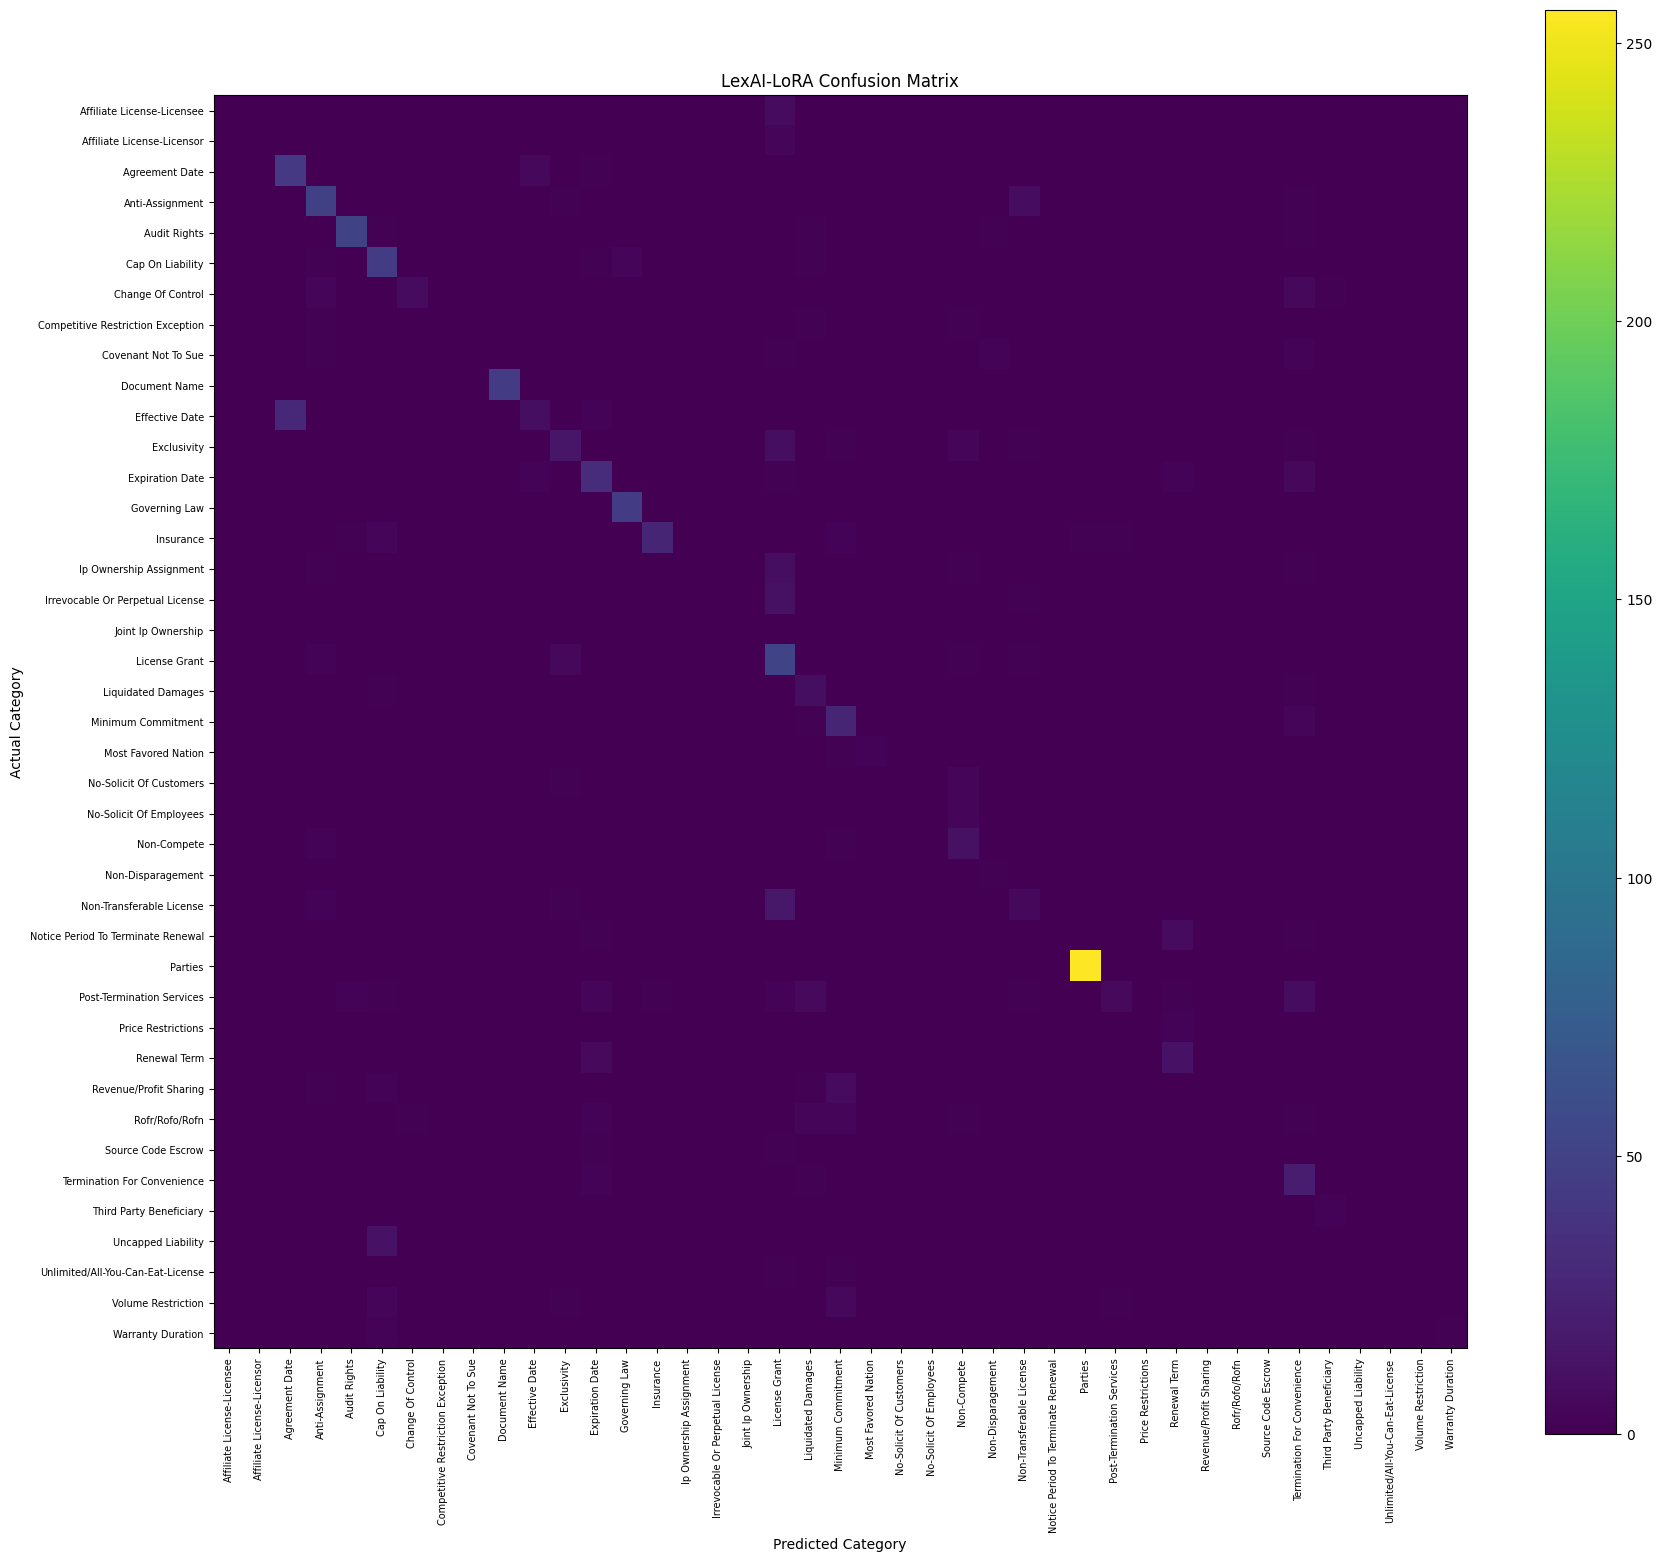

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 16))

plt.imshow(cm, interpolation="nearest")
plt.title("LexAI-LoRA Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.xticks(
    range(len(labels)),
    labels,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(labels)),
    labels,
    fontsize=7
)

plt.colorbar()

plt.tight_layout()
plt.show()

In [25]:
# Save the trained LoRA adapter and tokenizer

model.save_pretrained("LexAI-LoRA")
tokenizer.save_pretrained("LexAI-LoRA")

print("LexAI-LoRA model saved successfully!")

LexAI-LoRA model saved successfully!


In [26]:
import torch

def classify_clause(clause):

    prompt = alpaca_prompt.format(
        "Classify the following legal contract clause into its appropriate category.",
        clause,
        ""
    )

    inputs = tokenizer(
        [prompt],
        return_tensors="pt"
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=20,
            use_cache=True
        )

    generated = tokenizer.batch_decode(
        outputs,
        skip_special_tokens=True
    )[0]

    prediction = generated.split("### Response:")[-1].strip()
    prediction = prediction.split("\n")[0].strip()

    return prediction


test_clauses = [
    "Either party may terminate this Agreement upon thirty days written notice.",

    "The receiving party shall maintain all Confidential Information in strict confidence.",

    "This Agreement shall be governed by and construed in accordance with the laws of the State of California.",

    "The liability of either party shall not exceed the total fees paid under this Agreement.",

    "The license granted under this Agreement may not be transferred or assigned to any third party."
]

for i, clause in enumerate(test_clauses, 1):
    prediction = classify_clause(clause)

    print(f"\nTest Clause {i}:")
    print(clause)
    print("Predicted Category:", prediction)


Test Clause 1:
Either party may terminate this Agreement upon thirty days written notice.
Predicted Category: Termination For Convenience

Test Clause 2:
The receiving party shall maintain all Confidential Information in strict confidence.
Predicted Category: Confidentiality

Test Clause 3:
This Agreement shall be governed by and construed in accordance with the laws of the State of California.
Predicted Category: Governing Law

Test Clause 4:
The liability of either party shall not exceed the total fees paid under this Agreement.
Predicted Category: Cap On Liability

Test Clause 5:
The license granted under this Agreement may not be transferred or assigned to any third party.
Predicted Category: Anti-Assignment


## 8. Results and Discussion

The fine-tuned LexAI-LoRA model was evaluated on the held-out CUAD test set containing 1,316 samples across 41 legal clause categories.

### Quantitative Results

| Metric | Score |
|---|---:|
| Accuracy | 58.81% |
| Weighted Precision | 60.49% |
| Weighted Recall | 58.81% |
| Weighted F1 Score | 57.92% |

The model performs well on several clearly defined clause categories. Higher F1-scores were observed for categories such as **Parties, Document Name, Governing Law, Audit Rights, Anti-Assignment, and Agreement Date**.

Some categories were more difficult to distinguish because their legal wording and meaning overlap. For example, **Effective Date** was sometimes predicted as **Agreement Date**, while several license-related categories were confused with **License Grant**.

### Example Predictions

The model was also tested on new legal clauses outside the training examples:

| Legal Clause Type | Predicted Category |
|---|---|
| Termination with written notice | Termination For Convenience |
| Confidential information | Confidentiality |
| Applicable state law | Governing Law |
| Liability limited to fees | Cap On Liability |
| Non-transferable license | Anti-Assignment |

These examples demonstrate that the adapted model can identify several common legal clause types from their textual meaning.

### Discussion

The results show that LoRA-based fine-tuning can adapt a general-purpose language model toward a specialized legal classification task while updating only a small portion of the model parameters.

However, the current model is a prototype trained for a limited number of steps. Performance can be improved through longer training, better handling of class imbalance, and further evaluation on unseen legal documents.

## 9.Features of LexAI-LoRA

The main features of the developed LexAI-LoRA model are:

- **Legal Clause Classification:** Identifies the appropriate category of a given contract clause.
- **Domain Adaptation:** Adapted Qwen2.5 toward the legal contract domain using the CUAD dataset.
- **Parameter-Efficient Fine-Tuning:** Uses LoRA instead of updating the complete language model.
- **Memory Efficient:** Uses 4-bit quantization during fine-tuning, making it suitable for limited GPU resources.
- **Lightweight Adapter:** Only the LoRA parameters need to be stored separately from the base model.
- **Fast Inference:** Unsloth provides an optimized environment for efficient model training and inference.
- **Multiple Clause Categories:** Supports classification across the 41 categories present in the CUAD dataset.
- **Reusable Model:** The trained LoRA adapter can be loaded with the compatible Qwen2.5 base model.

## 10. Limitations and Future Scope

### Limitations

- The current model was trained for a limited number of steps and therefore represents a prototype.
- Some legally similar categories are difficult to distinguish from their wording alone.
- The CUAD dataset contains an imbalance between different clause categories.
- The model may produce incorrect classifications for clauses that are ambiguous or outside the training domain.
- The model is intended for research and experimentation and should not be treated as a substitute for professional legal advice.

### Future Scope

- Increase the number of training steps and experiment with different LoRA configurations.
- Apply techniques to handle class imbalance more effectively.
- Evaluate the model on additional legal contract datasets.
- Compare LexAI-LoRA with a general-purpose Qwen2.5 model without fine-tuning.
- Develop a simple interface where users can enter contract clauses and receive predicted categories.
- Extend the system to support automatic clause extraction and contract analysis.

## 11. Conclusion

This project demonstrated the use of **LoRA-based domain adaptation** for adapting Qwen2.5 to a specialized legal contract classification task.

The CUAD dataset was converted into an instruction-based format and used to fine-tune Qwen2.5 with LoRA using Unsloth and 4-bit quantization.

LexAI-LoRA achieved an **accuracy of 58.81%** and a **weighted F1-score of 57.92%** on the held-out test set. The model also successfully classified several new legal clauses during manual testing.

The project shows that parameter-efficient fine-tuning can be used to develop a lightweight domain-specific model while avoiding the need to update the complete set of language model parameters.

Overall, **LexAI-LoRA provides a practical prototype for automated legal contract clause classification** and can be further improved through longer training, better handling of class imbalance, and evaluation on additional legal datasets.